In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import os
os.chdir(r'C:\Users\bindh\Downloads\archive')
store = pd.read_csv('SampleSuperstore.csv', encoding='latin')
store.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [42]:
store.shape

(9994, 13)

In [43]:
store.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [44]:
dups = store[store.duplicated()]
print(len(dups))
store = store[~store.duplicated()]

17


In [45]:
total_sales = store['Sales'].sum()
total_profit = store['Profit'].sum()

print(round(total_sales,2))
print(round(total_profit,2))
print(round((total_profit/total_sales)*100,2))

2296195.59
286241.42
12.47


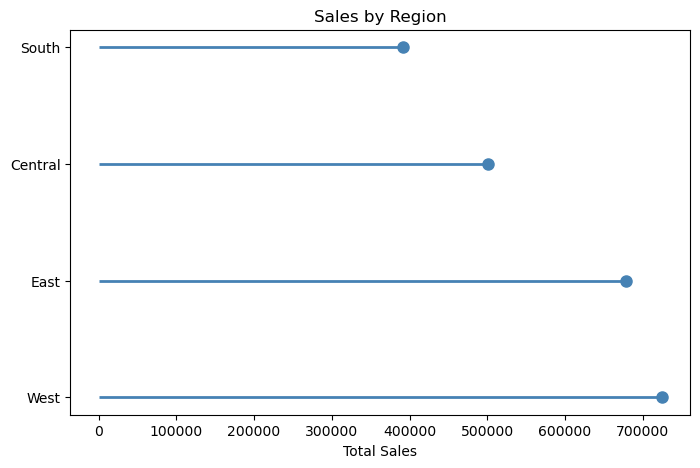

In [46]:
west_east = store.groupby('Region')['Sales'].sum()
west_east = west_east.sort_values(ascending=False)

fig,ax1 = plt.subplots(figsize=(8,5))
ax1.hlines(y=west_east.index, xmin=0, xmax=west_east.values, color='steelblue', linewidth=2)
ax1.plot(west_east.values, west_east.index,'o',color='steelblue',markersize=8)
ax1.set_title('Sales by Region')
ax1.set_xlabel('Total Sales')
fig.savefig('sales_by_region.png',bbox_inches='tight')
plt.show()

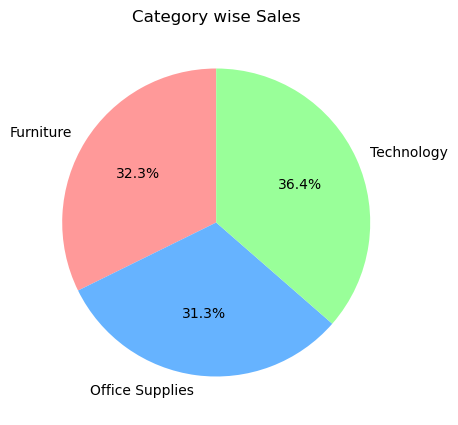

In [47]:
cat_sales = store.groupby('Category')['Sales'].sum()

fig,ax2 = plt.subplots(figsize=(6,5))
ax2.pie(cat_sales.values, labels=cat_sales.index,autopct='%1.1f%%',startangle=90,colors=['#ff9999','#66b3ff','#99ff99'])
ax2.set_title('Category wise Sales')
fig.savefig('sales_by_category.png',bbox_inches='tight')
plt.show()

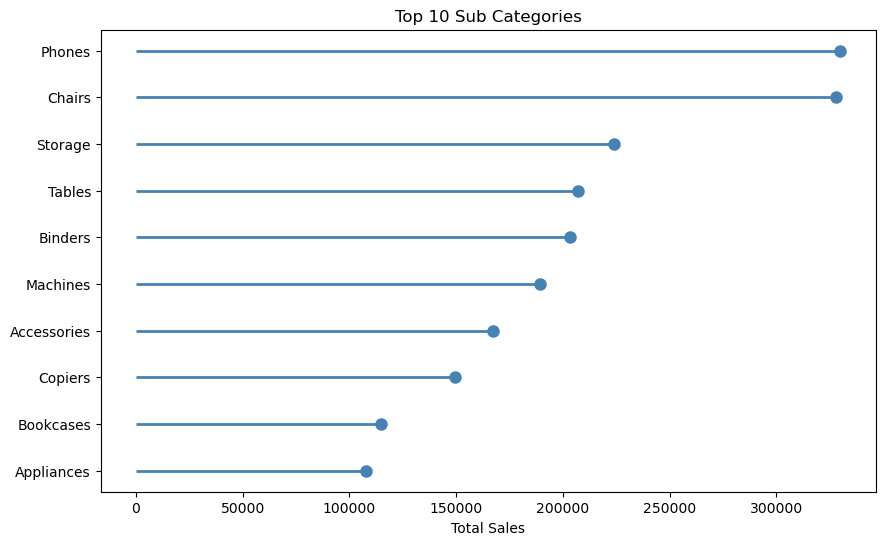

In [48]:
phones_chairs = store.groupby('Sub-Category')['Sales'].sum()
phones_chairs = phones_chairs.sort_values(ascending=True).tail(10)

fig,ax3=plt.subplots(figsize=(10,6))
ax3.hlines(y=phones_chairs.index,xmin=0,xmax=phones_chairs.values,color='steelblue',linewidth=2)
ax3.plot(phones_chairs.values,phones_chairs.index,'o',color='steelblue',markersize=8)
ax3.set_title('Top 10 Sub Categories')
ax3.set_xlabel('Total Sales')
fig.savefig('top_products.png',bbox_inches='tight')
plt.show()

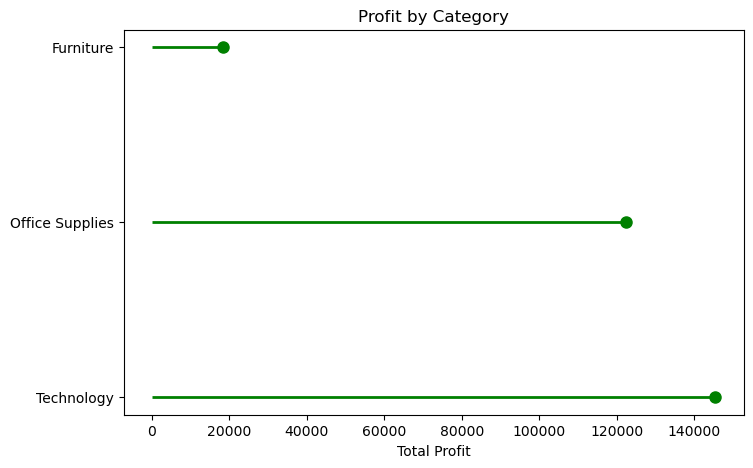

In [49]:
tech_furniture = store.groupby('Category')['Profit'].sum()
tech_furniture = tech_furniture.sort_values(ascending=False)

dot_colors = ['green' if v > 0 else 'red' for v in tech_furniture.values]

fig,ax4=plt.subplots(figsize=(8,5))
ax4.hlines(y=tech_furniture.index,xmin=0,xmax=tech_furniture.values,
           color=dot_colors,linewidth=2)
for i,(val,col) in enumerate(zip(tech_furniture.values, dot_colors)):
    ax4.plot(val, tech_furniture.index[i],'o',color=col,markersize=8)
ax4.set_title('Profit by Category')
ax4.set_xlabel('Total Profit')
fig.savefig('profit_by_category.png',bbox_inches='tight')
plt.show()

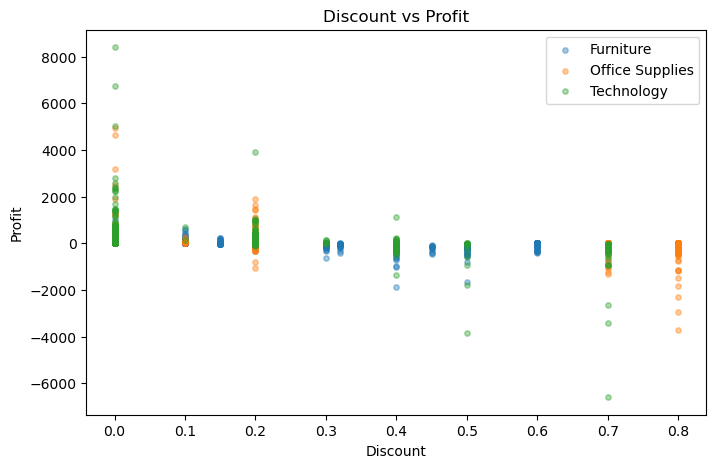

In [50]:
fig,ax5=plt.subplots(figsize=(8,5))
for cat in store['Category'].unique():
    temp=store[store['Category']==cat]
    ax5.scatter(temp['Discount'],temp['Profit'],label=cat,alpha=0.4,s=15)
ax5.set_title('Discount vs Profit')
ax5.set_xlabel('Discount')
ax5.set_ylabel('Profit')
ax5.legend()
fig.savefig('discount_vs_profit.png',bbox_inches='tight')
plt.show()

In [51]:
print(west_east.idxmax())
print(west_east.idxmin())
print(tech_furniture.idxmax())
print(tech_furniture.idxmin())
print(phones_chairs.idxmax())

West
South
Technology
Furniture
Phones


In [54]:
import sqlite3

conn = sqlite3.connect('superstore.db')
store.to_sql('superstore', conn, if_exists='replace', index=False)
print("database ready")


database ready


In [55]:
q1 = pd.read_sql_query("""
    SELECT 
        ROUND(SUM(Sales), 2) AS total_revenue,
        ROUND(SUM(Profit), 2) AS total_profit,
        ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS margin
    FROM superstore
""", conn)
print("overall numbers")
q1

overall numbers


,total_revenue,total_profit,margin
0,2296195.59,286241.42,12.47


In [56]:
q1 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Region
    ORDER BY Total_Sales DESC
""", conn)
print(" Sales & Profit by Region")
print(q1)
print()

 Sales & Profit by Region
    Region  Total_Sales  Total_Profit
0     West    725255.64     108329.81
1     East    678435.20      91506.31
2  Central    500782.85      39655.88
3    South    391721.91      46749.43



In [57]:
q2 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)
print(" Sales & Profit by Category")
print(q2)
print()

 Sales & Profit by Category
          Category  Total_Sales  Total_Profit
0       Technology    836154.03     145454.95
1        Furniture    741306.31      18421.81
2  Office Supplies    718735.24     122364.66



In [58]:
q3 = pd.read_sql_query("""
    SELECT [Sub-Category],
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM superstore
    GROUP BY [Sub-Category]
    ORDER BY Total_Sales DESC
    LIMIT 10
""", conn)
print(" Top 10 Sub-Categories")
print(q3)
print()

 Top 10 Sub-Categories
  Sub-Category  Total_Sales
0       Phones    330007.05
1       Chairs    327777.76
2      Storage    223843.61
3       Tables    206965.53
4      Binders    203409.17
5     Machines    189238.63
6  Accessories    167380.32
7      Copiers    149528.03
8    Bookcases    114880.00
9   Appliances    107532.16



In [59]:
q4 = pd.read_sql_query("""
    SELECT [Sub-Category],
           ROUND(SUM(Profit), 2) AS Total_Profit
    FROM superstore
    GROUP BY [Sub-Category]
    HAVING Total_Profit < 0
    ORDER BY Total_Profit ASC
""", conn)
print(" Loss Making Sub-Categories")
print(q4)
print()

 Loss Making Sub-Categories
  Sub-Category  Total_Profit
0       Tables     -17725.48
1    Bookcases      -3472.56
2     Supplies      -1189.10



In [60]:
q5 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales), 2) AS Total_Sales,
           ROUND(SUM(Profit), 2) AS Total_Profit,
           ROUND((SUM(Profit)/SUM(Sales))*100, 2) AS Profit_Margin
    FROM superstore
    GROUP BY Region
    ORDER BY Profit_Margin DESC
""", conn)
print(" Profit Margin by Region")
print(q5)
print()

conn.close()
print(" All SQL Queries Done!")

 Profit Margin by Region
    Region  Total_Sales  Total_Profit  Profit_Margin
0     West    725255.64     108329.81          14.94
1     East    678435.20      91506.31          13.49
2    South    391721.91      46749.43          11.93
3  Central    500782.85      39655.88           7.92

 All SQL Queries Done!


In [61]:
sql_queries = """
"""
with open('queries.sql', 'w') as f:
    f.write(sql_queries)

print(" queries.sql file saved!")

 queries.sql file saved!
